# Linear and Regularized Regression

## Loading the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys

# Add project root to path
sys.path.insert(0, str(Path().resolve().parent))

from config import DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

# ── Load datasets ──────────────────────────────────────────────────────────
# df_proc  → fully encoded: log1p numerics + ordinal + one-hot + engineered (216 numeric features)
#            use for regularization and full modeling
# df_ols → readable: log1p numerics + ordinal + engineered, nominal cols still as strings (92 cols)
#            use for simple OLS and coefficient interpretation
df_proc  = pd.read_csv(DATA_PROCESSED / "housing_processed.csv",
                       index_col=0)   # unnamed0 row-index → 223 columns
df_ols = pd.read_csv(DATA_PROCESSED / "housing_ols_ready.csv",
                       index_col=0)   # unnamed0 row-index → 92 columns

# Both files contain the same 2,927 observations after Ch 3 outlier removal.
# salePrice is already log-transformed in both files (applied in Ch 3).
df_proc.reset_index(drop=True, inplace=True)
df_ols.reset_index(drop=True, inplace=True)

y_all = df_proc["salePrice"].values    # log scale, full encoded dataset
y_ols = df_ols["salePrice"].values   # log scale, readable dataset

print(f"Encoded dataset:  {df_proc.shape[0]:,} rows, {df_proc.shape[1]} columns")
print(f"Readable dataset: {df_ols.shape[0]:,} rows, {df_ols.shape[1]} columns")
print(f"\nTarget — log(salePrice):")
print(f"  mean = {y_ols.mean():.4f},  std = {y_ols.std():.4f}")
print(f"  min  = {y_ols.min():.4f},  max  = {y_ols.max():.4f}")

Encoded dataset:  2,927 rows, 223 columns
Readable dataset: 2,927 rows, 92 columns

Target — log(salePrice):
  mean = 12.0209,  std = 0.4077
  min  = 9.4564,  max  = 13.5345


## Simple Linear Regression

### The Model

In [2]:
import statsmodels.formula.api as smf

# ── Simple regression: log(SalePrice) ~ overallQual ───────────────────────
m_qual = smf.ols("salePrice ~ overallQual", data=df_ols).fit()

print(m_qual.summary().tables[1])
print(f"\nR² = {m_qual.rsquared:.4f}")
print(f"RMSE = {np.sqrt(m_qual.mse_resid):.4f} log-units")

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      10.5575      0.019    562.530      0.000      10.521      10.594
overallQual     0.2403      0.003     80.026      0.000       0.234       0.246

R² = 0.6865
RMSE = 0.2284 log-units


### Visualising the Fit

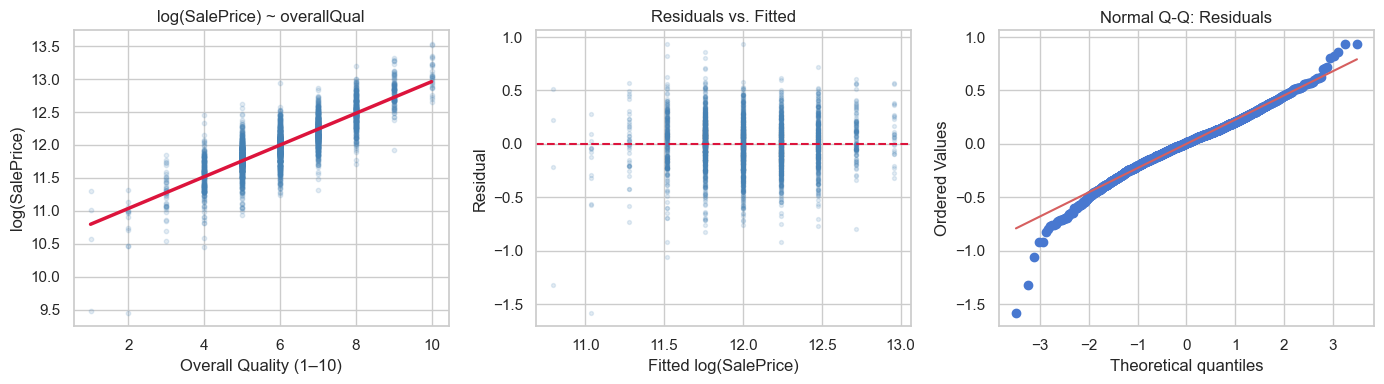

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: scatter with regression line
x_plot = np.linspace(df_ols["overallQual"].min(),
                     df_ols["overallQual"].max(), 200)
y_pred_line = m_qual.params["Intercept"] + m_qual.params["overallQual"] * x_plot

axes[0].scatter(df_ols["overallQual"], df_ols["salePrice"],
                alpha=0.15, s=10, color="steelblue")
axes[0].plot(x_plot, y_pred_line, color="crimson", lw=2.5)
axes[0].set_title("log(SalePrice) ~ overallQual")
axes[0].set_xlabel("Overall Quality (1–10)")
axes[0].set_ylabel("log(SalePrice)")

# Panel 2: fitted vs. residuals
fitted   = m_qual.fittedvalues
residuals = m_qual.resid
axes[1].scatter(fitted, residuals, alpha=0.15, s=8, color="steelblue")
axes[1].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[1].set_title("Residuals vs. Fitted")
axes[1].set_xlabel("Fitted log(SalePrice)")
axes[1].set_ylabel("Residual")

# Panel 3: Normal Q-Q of residuals
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q: Residuals")

plt.tight_layout()
plt.savefig(FIGURES / "ch06_slr_qual.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparing Two Simple Models

In [4]:
# ── Simple regression: log(SalePrice) ~ grLivArea ─────────────────────────
m_area = smf.ols("salePrice ~ grLivArea", data=df_ols).fit()

print("Model comparison: single predictors")
print(f"{'Predictor':15s}  {'β₁':>10}  {'R²':>8}  {'RMSE':>8}  {'AIC':>10}")
print("-" * 58)
for name, m, col in [("overallQual", m_qual, "overallQual"),
                      ("grLivArea",   m_area,  "grLivArea")]:
    print(f"{name:15s}  {m.params[col]:>10.4f}  "
          f"{m.rsquared:>8.4f}  "
          f"{np.sqrt(m.mse_resid):>8.4f}  "
          f"{m.aic:>10.2f}")

Model comparison: single predictors
Predictor                β₁        R²      RMSE         AIC
----------------------------------------------------------
overallQual          0.2403    0.6865    0.2284     -336.57
grLivArea            0.9226    0.5307    0.2794      843.72


## Multiple Regression

### The Multiple Regression Model

### Fitting a Multiple Regression Model

In [5]:
# Model 1: quality + size
m1 = smf.ols(
    "salePrice ~ overallQual + grLivArea",
    data=df_ols
).fit()

# Model 2: add age and basement
m2 = smf.ols(
    "salePrice ~ overallQual + grLivArea + houseAge + totalBsmtSf",
    data=df_ols
).fit()

# Model 3: add bathrooms, garage, kitchen quality
m3 = smf.ols(
    "salePrice ~ overallQual + grLivArea + houseAge + totalBsmtSf"
    " + totalBathrooms + garageCars + kitchenQual",
    data=df_ols
).fit()

# Model 4: add engineered interaction + neighbourhood (top 5)
# qualityAreaInt is already present in df_ols — built and saved by Ch 3
# neighborhood is still a string column in the readable dataset; create a
# binary indicator for the five highest-volume neighbourhoods
top5 = df_ols["neighborhood"].value_counts().head(5).index.tolist()
df_ols["inTop5Nbhd"] = df_ols["neighborhood"].isin(top5).astype(int)

m4 = smf.ols(
    "salePrice ~ overallQual + grLivArea + houseAge + totalBsmtSf"
    " + totalBathrooms + garageCars + kitchenQual"
    " + qualityAreaInt + inTop5Nbhd",
    data=df_ols
).fit()

# ── Model comparison table ─────────────────────────────────────────────────
models = {"M1: quality+size": m1, "M2: +age+bsmt": m2,
          "M3: +bath+gar+kitch": m3, "M4: +interact+nbhd": m4}

print(f"{'Model':22s}  {'p':>3}  {'R²':>7}  {'Adj R²':>8}  "
      f"{'RMSE':>7}  {'AIC':>10}")
print("-" * 68)
for label, m in models.items():
    p = len(m.params) - 1
    rmse = np.sqrt(m.mse_resid)
    print(f"{label:22s}  {p:>3}  {m.rsquared:>7.4f}  "
          f"{m.rsquared_adj:>8.4f}  {rmse:>7.4f}  {m.aic:>10.2f}")

Model                     p       R²    Adj R²     RMSE         AIC
--------------------------------------------------------------------
M1: quality+size          2   0.7744    0.7743   0.1937    -1298.21
M2: +age+bsmt             4   0.8392    0.8390   0.1636    -2284.64
M3: +bath+gar+kitch       7   0.8562    0.8558   0.1548    -2605.52
M4: +interact+nbhd        9   0.8568    0.8563   0.1546    -2613.84


### Interpreting Coefficients

In [6]:
print(m4.summary().tables[1])

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          8.9417      0.241     37.100      0.000       8.469       9.414
overallQual       -0.0221      0.040     -0.557      0.578      -0.100       0.056
grLivArea          0.2761      0.033      8.282      0.000       0.211       0.341
houseAge          -0.0016      0.000    -11.900      0.000      -0.002      -0.001
totalBsmtSf        0.0002   8.36e-06     21.264      0.000       0.000       0.000
totalBathrooms     0.0438      0.005      8.530      0.000       0.034       0.054
garageCars         0.0544      0.005     10.535      0.000       0.044       0.064
kitchenQual        0.0644      0.006     10.513      0.000       0.052       0.076
qualityAreaInt     0.0151      0.005      2.774      0.006       0.004       0.026
inTop5Nbhd        -0.0114      0.006     -1.936      0.053      -0.023       0.000


### Model Fit: $R^2$, Adjusted $R^2$, and AIC

### Visualising Multiple Regression Fit

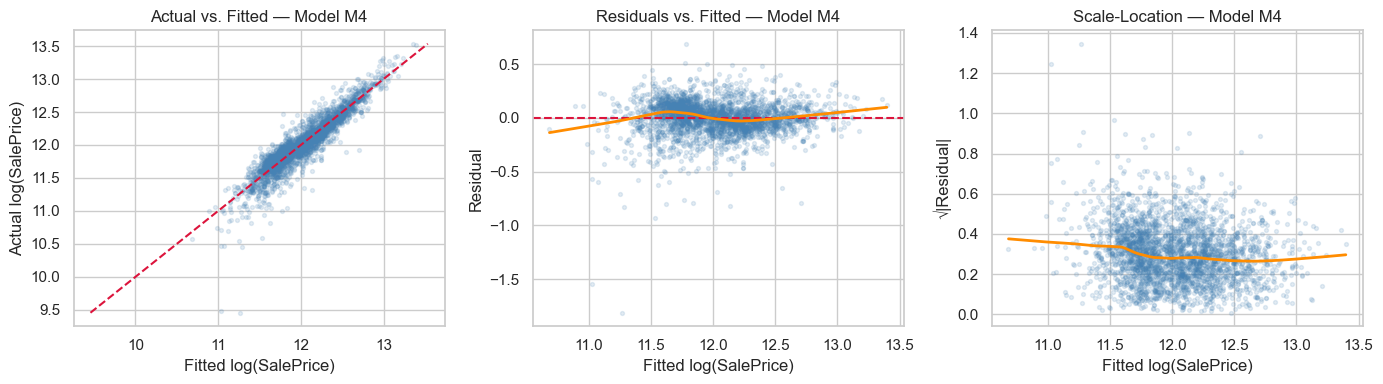

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

fitted_m4    = m4.fittedvalues
residuals_m4 = m4.resid
# m4 drops 3 NaN rows internally; use m4.model.endog for the matching actual values
actual_m4    = m4.model.endog

# Panel 1: Actual vs. fitted
axes[0].scatter(fitted_m4, actual_m4, alpha=0.15, s=8, color="steelblue")
lims = [min(fitted_m4.min(), actual_m4.min()),
        max(fitted_m4.max(), actual_m4.max())]
axes[0].plot(lims, lims, color="crimson", lw=1.5, linestyle="--")
axes[0].set_title("Actual vs. Fitted — Model M4")
axes[0].set_xlabel("Fitted log(SalePrice)")
axes[0].set_ylabel("Actual log(SalePrice)")

# Panel 2: Residuals vs. fitted
axes[1].scatter(fitted_m4, residuals_m4, alpha=0.15, s=8, color="steelblue")
axes[1].axhline(0, color="crimson", lw=1.5, linestyle="--")
# Smooth trend line
from statsmodels.nonparametric.smoothers_lowess import lowess
smooth = lowess(residuals_m4, fitted_m4, frac=0.3)
axes[1].plot(smooth[:, 0], smooth[:, 1], color="darkorange", lw=2)
axes[1].set_title("Residuals vs. Fitted — Model M4")
axes[1].set_xlabel("Fitted log(SalePrice)")
axes[1].set_ylabel("Residual")

# Panel 3: Scale-location (sqrt |residuals|)
axes[2].scatter(fitted_m4, np.sqrt(np.abs(residuals_m4)),
                alpha=0.15, s=8, color="steelblue")
smooth2 = lowess(np.sqrt(np.abs(residuals_m4)), fitted_m4, frac=0.3)
axes[2].plot(smooth2[:, 0], smooth2[:, 1], color="darkorange", lw=2)
axes[2].set_title("Scale-Location — Model M4")
axes[2].set_xlabel("Fitted log(SalePrice)")
axes[2].set_ylabel("√|Residual|")

plt.tight_layout()
plt.savefig(FIGURES / "ch06_mlr_fit.png", dpi=150, bbox_inches="tight")
plt.show()

## Model Assumptions and Diagnostics

### Diagnostic Plots: Full Panel

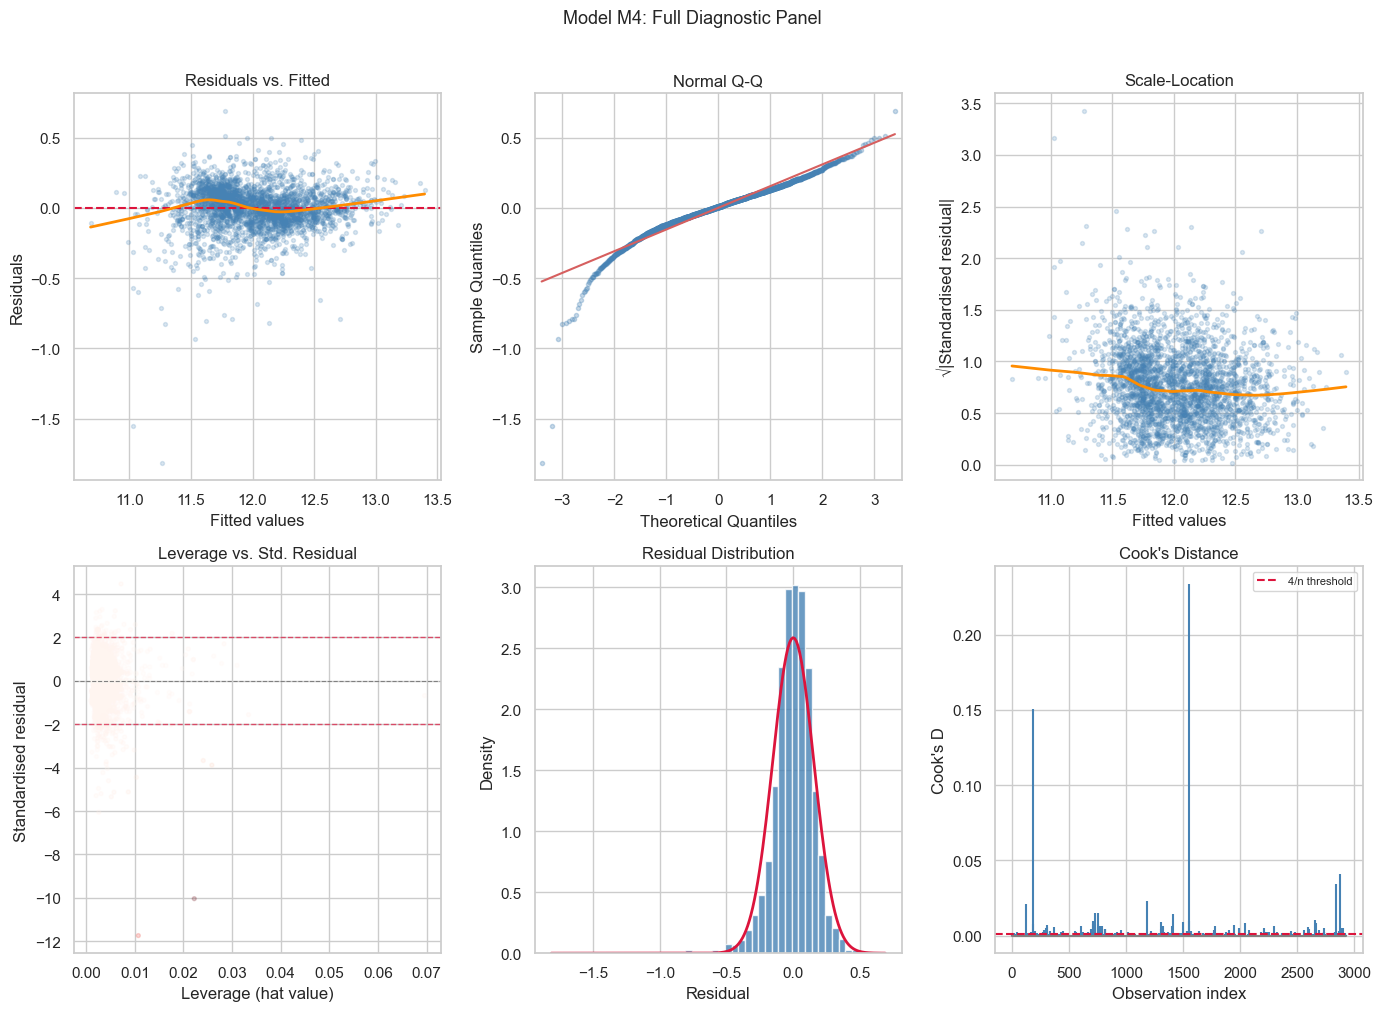

In [8]:
from statsmodels.graphics.gofplots import ProbPlot

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

fitted_m4    = m4.fittedvalues
residuals_m4 = m4.resid
std_resid    = residuals_m4 / residuals_m4.std()
influence    = m4.get_influence()
leverage     = influence.hat_matrix_diag
cooks        = influence.cooks_distance[0]

# Panel 1: Residuals vs. Fitted + LOWESS
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(fitted_m4, residuals_m4, alpha=0.2, s=8, color="steelblue")
ax1.axhline(0, color="crimson", lw=1.5, linestyle="--")
smooth = lowess(residuals_m4.values, fitted_m4.values, frac=0.3)
ax1.plot(smooth[:, 0], smooth[:, 1], color="darkorange", lw=2)
ax1.set_title("Residuals vs. Fitted")
ax1.set_xlabel("Fitted values")
ax1.set_ylabel("Residuals")

# Panel 2: Normal Q-Q
ax2 = fig.add_subplot(gs[0, 1])
pp  = ProbPlot(residuals_m4)
pp.qqplot(ax=ax2, line="s", alpha=0.3, markersize=3, 
          markerfacecolor="steelblue",
          markeredgecolor="steelblue")
ax2.set_title("Normal Q-Q")

# Panel 3: Scale-Location
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(fitted_m4, np.sqrt(np.abs(std_resid)),
            alpha=0.2, s=8, color="steelblue")
smooth2 = lowess(np.sqrt(np.abs(std_resid.values)), fitted_m4.values, frac=0.3)
ax3.plot(smooth2[:, 0], smooth2[:, 1], color="darkorange", lw=2)
ax3.set_title("Scale-Location")
ax3.set_xlabel("Fitted values")
ax3.set_ylabel("√|Standardised residual|")

# Panel 4: Leverage vs. Residuals (Cook's distance)
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(leverage, std_resid, alpha=0.2, s=8,
            c=cooks, cmap="Reds")
ax4.axhline(0, color="grey", lw=0.8, linestyle="--")
ax4.axhline(2,  color="crimson", lw=1, linestyle="--", alpha=0.7)
ax4.axhline(-2, color="crimson", lw=1, linestyle="--", alpha=0.7)
ax4.set_title("Leverage vs. Std. Residual")
ax4.set_xlabel("Leverage (hat value)")
ax4.set_ylabel("Standardised residual")

# Panel 5: Histogram of residuals
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(residuals_m4, bins=50, color="steelblue", edgecolor="white",
         density=True, alpha=0.8)
x_norm = np.linspace(residuals_m4.min(), residuals_m4.max(), 200)
ax5.plot(x_norm,
         stats.norm.pdf(x_norm, residuals_m4.mean(), residuals_m4.std()),
         color="crimson", lw=2)
ax5.set_title("Residual Distribution")
ax5.set_xlabel("Residual")
ax5.set_ylabel("Density")

# Panel 6: Cook's distance
ax6 = fig.add_subplot(gs[1, 2])
ax6.stem(range(len(cooks)), cooks, markerfmt=" ", linefmt="steelblue",
         basefmt="grey")
ax6.axhline(4 / len(cooks), color="crimson", lw=1.5, linestyle="--",
            label=f"4/n threshold")
ax6.set_title("Cook's Distance")
ax6.set_xlabel("Observation index")
ax6.set_ylabel("Cook's D")
ax6.legend(fontsize=8)

plt.suptitle("Model M4: Full Diagnostic Panel", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "ch06_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### Formal Assumption Tests

In [9]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera

# Breusch–Pagan test for heteroscedasticity
bp_stat, bp_p, _, _ = het_breuschpagan(m4.resid, m4.model.exog)

# Jarque–Bera test for normality of residuals
jb_stat, jb_p, skew, kurt = jarque_bera(m4.resid)

# Durbin–Watson test for autocorrelation
dw = durbin_watson(m4.resid)

# Variance inflation factors
from statsmodels.stats.outliers_influence import variance_inflation_factor

exog_df = pd.DataFrame(m4.model.exog,
                       columns=m4.model.exog_names)
vif_data = pd.DataFrame({
    "Feature": exog_df.columns[1:],   # skip Intercept
    "VIF": [variance_inflation_factor(exog_df.values, i + 1)
            for i in range(exog_df.shape[1] - 1)]
}).sort_values("VIF", ascending=False)

print("── Assumption diagnostics ──────────────────────────────")
print(f"  Breusch–Pagan (heteroscedasticity): stat={bp_stat:.2f}, p={bp_p:.4f}")
print(f"  Jarque–Bera   (normality):          stat={jb_stat:.2f}, p={jb_p:.4f}")
print(f"  Durbin–Watson (autocorrelation):    DW={dw:.3f}")
print(f"\nVariance Inflation Factors (top 5):")
print(vif_data.head().to_string(index=False))

── Assumption diagnostics ──────────────────────────────
  Breusch–Pagan (heteroscedasticity): stat=140.06, p=0.0000
  Jarque–Bera   (normality):          stat=19866.21, p=0.0000
  Durbin–Watson (autocorrelation):    DW=1.636

Variance Inflation Factors (top 5):
       Feature        VIF
qualityAreaInt 479.165100
   overallQual 379.897155
     grLivArea  14.110626
      houseAge   2.147347
totalBathrooms   2.094079


### Train / Test Split and Out-of-Sample Evaluation

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Use the readable dataset for the nine-predictor OLS model (M4).
# All columns below were either original features or engineered features
# saved by Ch 3 — no re-computation needed here.
X_ols = df_ols[["overallQual", "grLivArea", "houseAge", "totalBsmtSf",
                   "totalBathrooms", "garageCars", "kitchenQual",
                   "qualityAreaInt", "inTop5Nbhd"]].values
y_ols = df_ols["salePrice"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_ols, y_ols, test_size=0.2, random_state=RANDOM_SEED
)

# Refit on training set
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X_tr, y_tr)
y_pred_te = lr.predict(X_te)

rmse_train = np.sqrt(mean_squared_error(y_tr, lr.predict(X_tr)))
rmse_test  = np.sqrt(mean_squared_error(y_te, y_pred_te))
r2_test    = r2_score(y_te, y_pred_te)

print(f"OLS Model M4 — Out-of-Sample Evaluation")
print(f"  Train RMSE: {rmse_train:.4f} log-units")
print(f"  Test  RMSE: {rmse_test:.4f} log-units")
print(f"  Test  R²:   {r2_test:.4f}")
print(f"  RMSE gap (overfitting signal): {rmse_test - rmse_train:.4f}")

OLS Model M4 — Out-of-Sample Evaluation
  Train RMSE: 0.1582 log-units
  Test  RMSE: 0.1382 log-units
  Test  R²:   0.8936
  RMSE gap (overfitting signal): -0.0200


## Regularization: Ridge and Lasso

### Fitting Ridge and Lasso with Cross-Validation

In [11]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Prepare full feature matrix from df_proc ──────────────────────────────
# df_proc has 223 columns (after unnamed0 is used as the index).
# Drop identifier columns (order, pID) and the target, then remove the 4
# string columns that were not fully encoded in the Ch 3 pipeline
# (utilities, bsmtfinType1, bsmtfinType2, fireplaceQu).
# This leaves 216 numeric feature columns ready for regularized modeling.
id_cols = ['order', 'pID']
non_numeric_cols = df_proc.select_dtypes(exclude=[np.number]).columns.tolist()
feature_cols = [c for c in df_proc.columns
                if c != "salePrice"
                and c not in id_cols
                and c not in non_numeric_cols]

X_df  = df_proc[feature_cols].fillna(df_proc[feature_cols].median())
X_all = X_df.values
y_all = df_proc["salePrice"].values

# Train / test split (same seed as before for comparability)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training set:  {X_tr.shape[0]:,} × {X_tr.shape[1]}")
print(f"Test set:      {X_te.shape[0]:,} × {X_te.shape[1]}")

# ── Ridge with 10-fold CV ──────────────────────────────────────────────────
alphas_ridge = np.logspace(-3, 4, 100)

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  RidgeCV(alphas=alphas_ridge, cv=10, scoring="neg_root_mean_squared_error"))
])
ridge_pipe.fit(X_tr, y_tr)
alpha_ridge_best = ridge_pipe.named_steps["ridge"].alpha_

# ── Lasso with 10-fold CV ──────────────────────────────────────────────────
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso",  LassoCV(alphas=np.logspace(-4, 0, 100), cv=10, max_iter=10_000,
                       random_state=RANDOM_SEED))
])
lasso_pipe.fit(X_tr, y_tr)
alpha_lasso_best = lasso_pipe.named_steps["lasso"].alpha_
lasso_coef       = lasso_pipe.named_steps["lasso"].coef_
n_nonzero        = (lasso_coef != 0).sum()

print(f"\nOptimal Ridge α: {alpha_ridge_best:.4f}")
print(f"Optimal Lasso α: {alpha_lasso_best:.4f}")
print(f"Lasso non-zero coefficients: {n_nonzero} / {len(lasso_coef)}")

Training set:  2,341 × 216
Test set:      586 × 216

Optimal Ridge α: 145.0829
Optimal Lasso α: 0.0022
Lasso non-zero coefficients: 108 / 216


### Evaluating All Models

In [12]:
from sklearn.linear_model import LinearRegression

# OLS on full encoded dataset
ols_all = Pipeline([
    ("scaler", StandardScaler()),
    ("ols",    LinearRegression())
])
ols_all.fit(X_tr, y_tr)

def eval_model(pipe, X_tr, y_tr, X_te, y_te, name):
    rmse_tr = np.sqrt(mean_squared_error(y_tr, pipe.predict(X_tr)))
    rmse_te = np.sqrt(mean_squared_error(y_te, pipe.predict(X_te)))
    r2_te   = r2_score(y_te, pipe.predict(X_te))
    return {"Model": name, "Train RMSE": rmse_tr,
            "Test RMSE": rmse_te, "Test R²": r2_te,
            "Gap": rmse_te - rmse_tr}

results = [
    eval_model(ols_all,    X_tr, y_tr, X_te, y_te, "OLS (216 features)"),
    eval_model(ridge_pipe, X_tr, y_tr, X_te, y_te, "Ridge (CV α)"),
    eval_model(lasso_pipe, X_tr, y_tr, X_te, y_te, "Lasso (CV α)"),
]

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False, float_format="{:.4f}".format))

             Model  Train RMSE  Test RMSE  Test R²     Gap
OLS (216 features)      0.1026     0.2759   0.5761  0.1734
      Ridge (CV α)      0.1055     0.0960   0.9487 -0.0096
      Lasso (CV α)      0.1084     0.0951   0.9497 -0.0133


### Regularization Paths

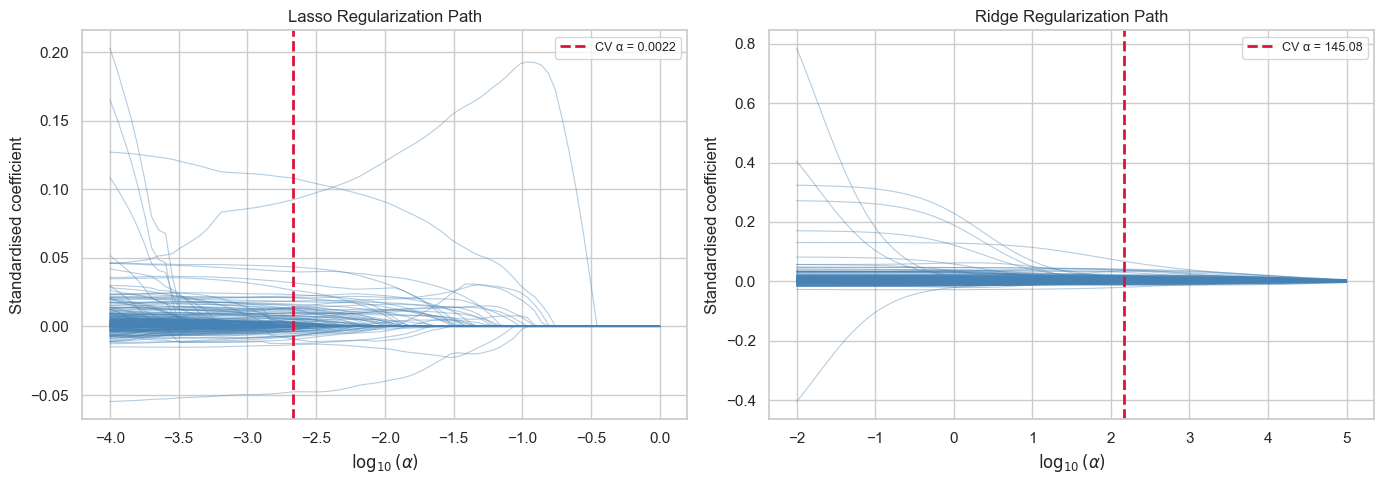

In [13]:
from sklearn.linear_model import lasso_path, ridge_regression

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Lasso path ─────────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
alphas_l, coefs_l, _ = lasso_path(X_tr_sc, y_tr,
                                   alphas=np.logspace(-4, 0, 80),
                                   max_iter=5_000)

for coef_path in coefs_l:
    axes[0].plot(np.log10(alphas_l), coef_path,
                 lw=0.8, alpha=0.4, color="steelblue")
axes[0].axvline(np.log10(alpha_lasso_best), color="crimson",
                lw=2, linestyle="--", label=f"CV α = {alpha_lasso_best:.4f}")
axes[0].set_title("Lasso Regularization Path")
axes[0].set_xlabel(r"$\log_{10}(\alpha)$")
axes[0].set_ylabel("Standardised coefficient")
axes[0].legend(fontsize=9)

# ── Ridge path ─────────────────────────────────────────────────────────────
alphas_r = np.logspace(-2, 5, 80)
coefs_r  = np.array([
    ridge_regression(X_tr_sc, y_tr, alpha=a, solver="svd")
    for a in alphas_r
])

for j in range(coefs_r.shape[1]):
    axes[1].plot(np.log10(alphas_r), coefs_r[:, j],
                 lw=0.8, alpha=0.4, color="steelblue")
axes[1].axvline(np.log10(alpha_ridge_best), color="crimson",
                lw=2, linestyle="--", label=f"CV α = {alpha_ridge_best:.2f}")
axes[1].set_title("Ridge Regularization Path")
axes[1].set_xlabel(r"$\log_{10}(\alpha)$")
axes[1].set_ylabel("Standardised coefficient")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "ch06_reg_paths.png", dpi=150, bbox_inches="tight")
plt.show()

### Lasso Feature Importance

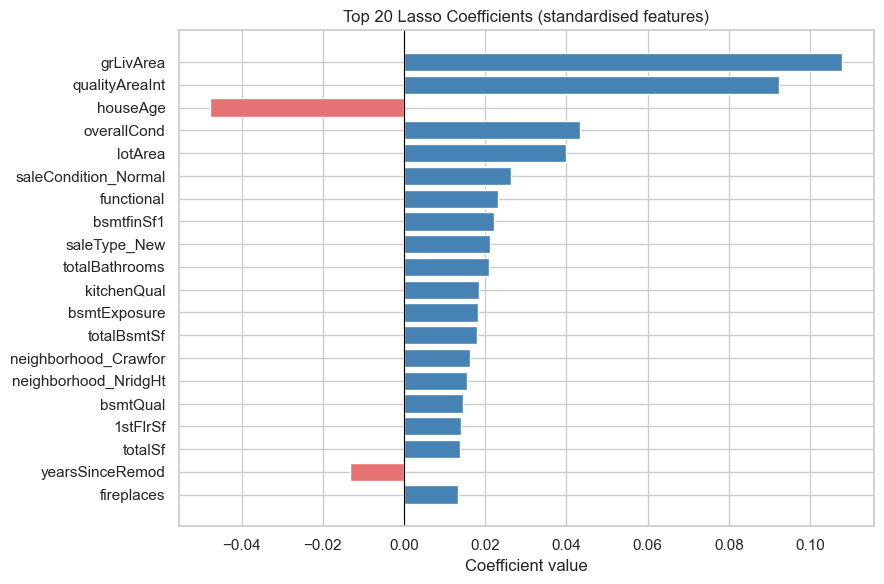

In [14]:
# Top retained features and their standardised coefficients
lasso_model  = lasso_pipe.named_steps["lasso"]
feat_names   = feature_cols
coef_df = (pd.DataFrame({"feature": feat_names,
                          "coef": lasso_model.coef_})
             .query("coef != 0")
             .reindex(columns=["feature", "coef"])
             .assign(abs_coef=lambda d: d["coef"].abs())
             .sort_values("abs_coef", ascending=False)
             .head(20))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["steelblue" if c > 0 else "#E57373" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 20 Lasso Coefficients (standardised features)")
ax.set_xlabel("Coefficient value")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES / "ch06_lasso_coefs.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualising Predictions: All Models

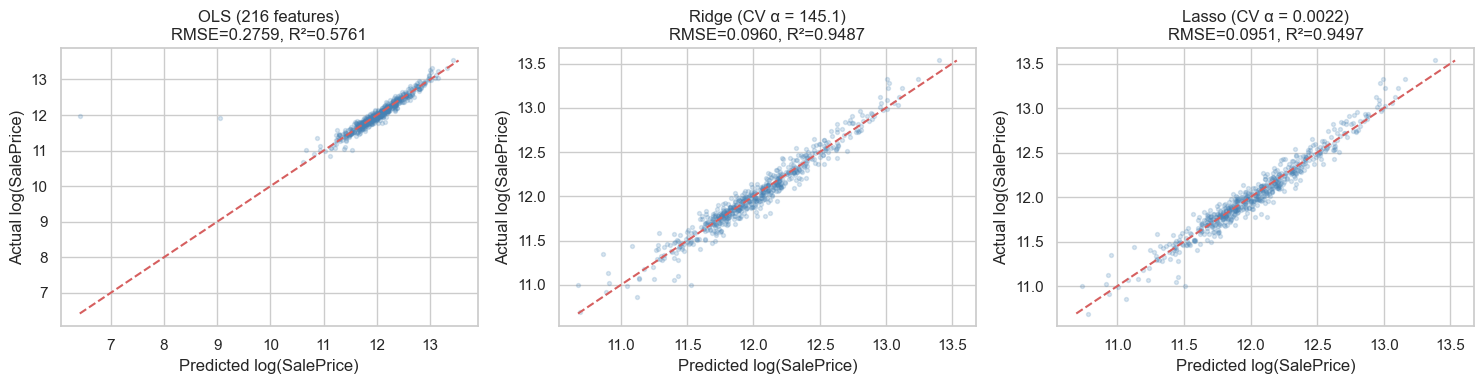

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_specs = [
    (ols_all,    "OLS (216 features)"),
    (ridge_pipe, "Ridge (CV α = {:.1f})".format(alpha_ridge_best)),
    (lasso_pipe, "Lasso (CV α = {:.4f})".format(alpha_lasso_best)),
]

for ax, (pipe, title) in zip(axes, model_specs):
    y_hat = pipe.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, y_hat))
    r2    = r2_score(y_te, y_hat)
    ax.scatter(y_hat, y_te, alpha=0.2, s=8, color="steelblue")
    lims = [min(y_hat.min(), y_te.min()), max(y_hat.max(), y_te.max())]
    ax.plot(lims, lims, "r--", lw=1.5)
    ax.set_title(f"{title}\nRMSE={rmse:.4f}, R²={r2:.4f}")
    ax.set_xlabel("Predicted log(SalePrice)")
    ax.set_ylabel("Actual log(SalePrice)")

plt.tight_layout()
plt.savefig(FIGURES / "ch06_predictions.png", dpi=150, bbox_inches="tight")
plt.show()